In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Classes: {data.target_names}")


Train size: (455, 30)
Test size: (114, 30)
Classes: ['malignant' 'benign']


In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
print("Model trained ✓")


Model trained ✓


In [3]:
import pandas as pd

probs = model.predict_proba(X_test)
preds = model.predict(X_test)
confidence = probs.max(axis=1)

df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": preds,
    "confidence": confidence
})
df["correct"] = df["y_true"] == df["y_pred"]

print(df.head(10))

print(f"\nTotal predictions: {len(df)}")


   y_true  y_pred  confidence  correct
0       1       1    0.878745     True
1       0       0    1.000000     True
2       0       0    0.998406     True
3       1       1    0.998779     True
4       1       1    0.999859     True
5       0       0    1.000000     True
6       0       0    1.000000     True
7       0       0    0.980755     True
8       1       1    0.984231     True
9       1       1    0.994355     True

Total predictions: 114


In [4]:
wrong = df[df["y_true"] != df["y_pred"]]
confident_wrong = wrong[wrong["confidence"] > 0.9]

print(f"Total wrong predictions: {len(wrong)}")
print(f"Confidently wrong (>90%): {len(confident_wrong)}")
print("\n--- Confidently Wrong Cases ---")
print(confident_wrong)


Total wrong predictions: 5
Confidently wrong (>90%): 1

--- Confidently Wrong Cases ---
     y_true  y_pred  confidence  correct
112       1       0    0.918034    False


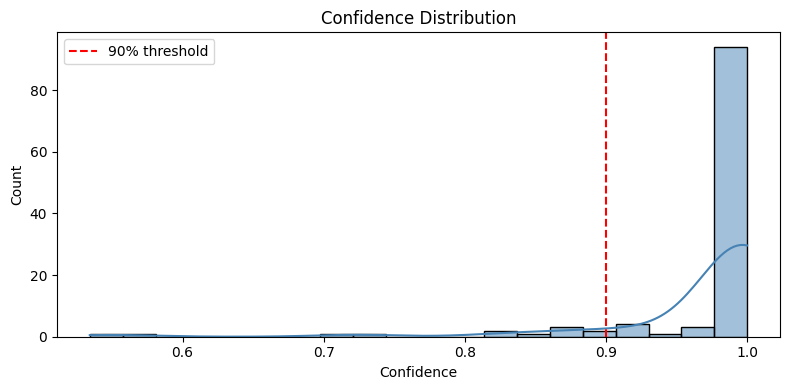

/var/folders/44/g8mx_txj09321s2ptbjz1vbh0000gn/T/ipykernel_11658/2516141802.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="correct", y="confidence", data=df, palette=["salmon", "mediumseagreen"])


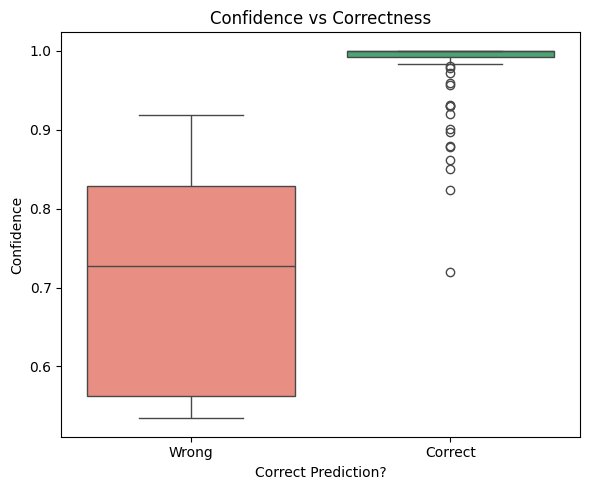

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(df["confidence"], bins=20, kde=True, color="steelblue")
plt.axvline(0.9, color="red", linestyle="--", label="90% threshold")
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/confidence_distribution.png", dpi=150)
plt.show()
plt.figure(figsize=(6, 5))
sns.boxplot(x="correct", y="confidence", data=df, palette=["salmon", "mediumseagreen"])
plt.xticks([0, 1], ["Wrong", "Correct"])
plt.title("Confidence vs Correctness")
plt.xlabel("Correct Prediction?")
plt.ylabel("Confidence")
plt.tight_layout()
plt.savefig("outputs/confidence_vs_correctness.png", dpi=150)
plt.show()


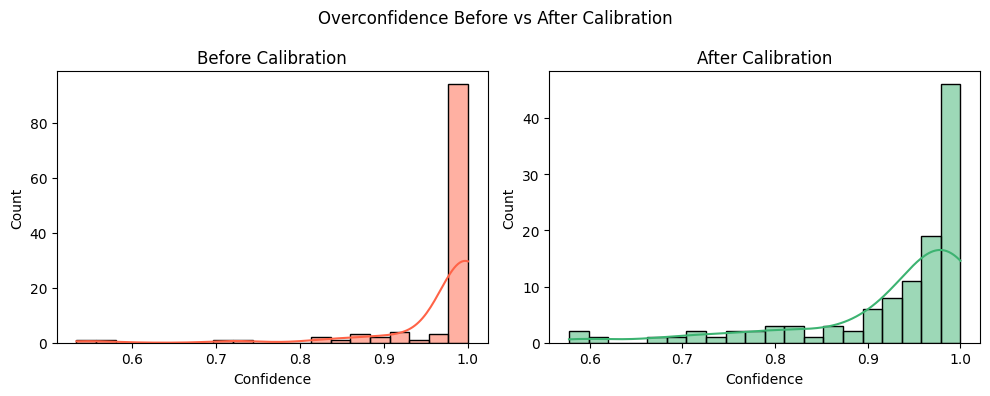

In [6]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

# Train a fresh model for calibration
base_model = LogisticRegression(max_iter=10000)
calibrated_model = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

cal_probs = calibrated_model.predict_proba(X_test)
cal_conf = cal_probs.max(axis=1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(confidence, bins=20, kde=True, color="tomato")
plt.title("Before Calibration")
plt.xlabel("Confidence")

plt.subplot(1, 2, 2)
sns.histplot(cal_conf, bins=20, kde=True, color="mediumseagreen")
plt.title("After Calibration")
plt.xlabel("Confidence")

plt.suptitle("Overconfidence Before vs After Calibration")
plt.tight_layout()
plt.savefig("outputs/calibration_comparison.png", dpi=150)
plt.show()
